In [1]:
import json
from PIL import Image
from torch.utils.data import Dataset

class ImageNet100Dataset(Dataset):
    def __init__(self, root_dir, indices=None):
        self.root_dir = root_dir
        with open(f"{root_dir}/labels.json") as f:
            self.labels = json.load(f)
        
        self.indices = indices if indices is not None else list(range(len(self.labels)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = Image.open(f"{self.root_dir}/imagenet100_128px/{real_idx}.jpg").convert("RGB")
        label = self.labels[real_idx]
        return img, label

In [2]:
import os

folder_path = '../data'
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(files)

with open("../data/labels.json") as f: 
    labels = json.load(f) 

['class_names.json', 'labels.json']


In [3]:
import json
import random

from matplotlib.pylab import tri

with open("../data/labels.json") as f: 
    labels = json.load(f) 
with open("../data/class_names.json") as f: # optional, just for reference
    class_names = json.load(f)  

SEED = 42
all_classes = list(range(100))
random.Random(SEED).shuffle(all_classes)

holdout_classes = set(all_classes[:20])
train_classes = set(all_classes[20:])

train_indices = [i for i, lbl in enumerate(labels) if lbl in train_classes]
holdout_indices = [i for i, lbl in enumerate(labels) if lbl in holdout_classes]

print(f"Train images: {len(train_indices)}")    
print(f"Holdout images: {len(holdout_indices)}")

train_base = ImageNet100Dataset("../data", indices=train_indices)
holdout_base = ImageNet100Dataset("../data", indices=holdout_indices)

img = Image.open(f"../data/imagenet100_128px/{train_indices[5]}.jpg").convert("RGB")
img, label = train_base[5]
label

Train images: 101712
Holdout images: 24977


0

In [4]:
def get_grid_positions(img_size=128, grid_size=3):
    """Fixed 3x3 grid cell coordinates - same every time, regardless of permutation."""
    patch_size = img_size // grid_size  # 128 // 3 ≈ 42
    positions = []
    for row in range(grid_size):
        for col in range(grid_size):
            x = col * patch_size
            y = row * patch_size
            positions.append((x, y))
    return positions  # always 9 fixed (x,y) pairs, e.g. [(0,0),(42,0),(84,0),(0,42),...]

In [5]:
class JigsawDataset(Dataset):
    def __init__(self, image_dataset, permutation_set, seed=None):
        self.image_dataset = image_dataset
        self.permutation_set = permutation_set
        self.rng = random.Random(seed)
        self.grid_positions = get_grid_positions() 

    def __len__(self):
        return len(self.image_dataset)

    def __getitem__(self, idx):
        img, label = self.image_dataset[idx]

        patch_size = 128 // 3
        patches = [
            img.crop((x, y, x + patch_size, y + patch_size))
            for (x, y) in self.grid_positions
        ]

        perm_index = self.rng.randint(0, len(self.permutation_set) - 1)
        perm = self.permutation_set[perm_index]  # e.g. (2, 0, 4, 1, 8, 5, 3, 7, 6)
        shuffled_patches = [patches[i] for i in perm]

        return shuffled_patches, perm_index

In [7]:
# Temp code:
from puzzly.data.permutations import generate_permutation_set, save_permutation_set, load_permutation_set

permutation_set = generate_permutation_set(num_patches=9, num_permutations=50, seed=42)
save_permutation_set(permutation_set, "../data/permutation_set.json")

permutation_set = load_permutation_set("../data/permutation_set.json")

In [ ]:
permutation_set = load_permutation_set("../data/permutation_set.json")

train_data = JigsawDataset(train_base, permutation_set=permutation_set, seed=SEED)
train_data[]

([<PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>,
  <PIL.Image.Image image mode=RGB size=42x42>],
 40)

In [14]:
def visualize_jigsaw(patches, grid_size=3):
    """Visualize the shuffled patches in a grid."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    for i, patch in enumerate(patches):
        row = i // grid_size
        col = i % grid_size
        axes[row, col].imshow(patch)
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

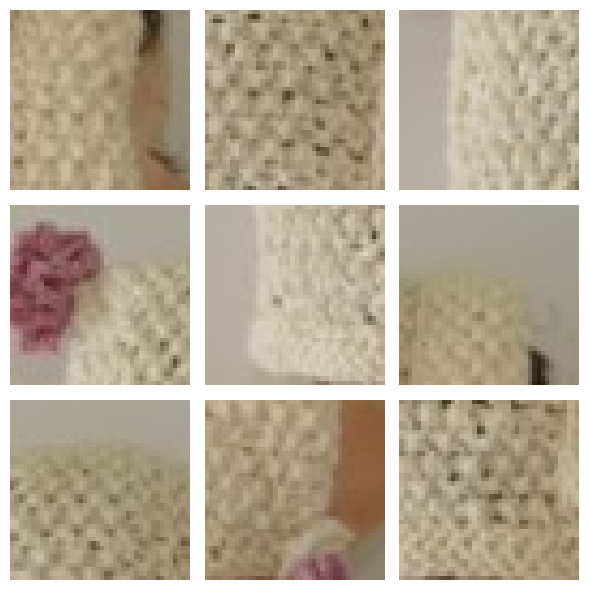

In [43]:
def unscramble_jigsaw(permutation_list, shuffled_patches, grid_size=3):
    """Reconstructs the original patch order from shuffled patches + the perm that was applied."""
    import matplotlib.pyplot as plt

    original_order = [0] * len(shuffled_patches)
    for i, patch_index in enumerate(permutation_list):
        original_order[patch_index] = shuffled_patches[i]

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    for i, patch in enumerate(original_order):
        row, col = i // grid_size, i % grid_size
        axes[row, col].imshow(patch)
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

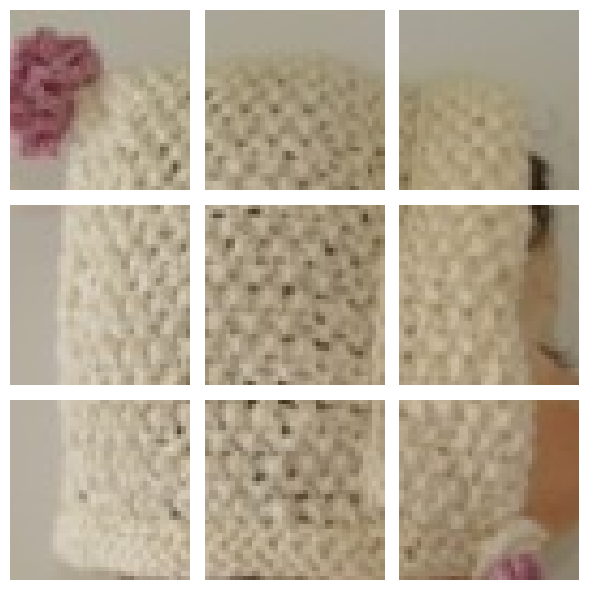

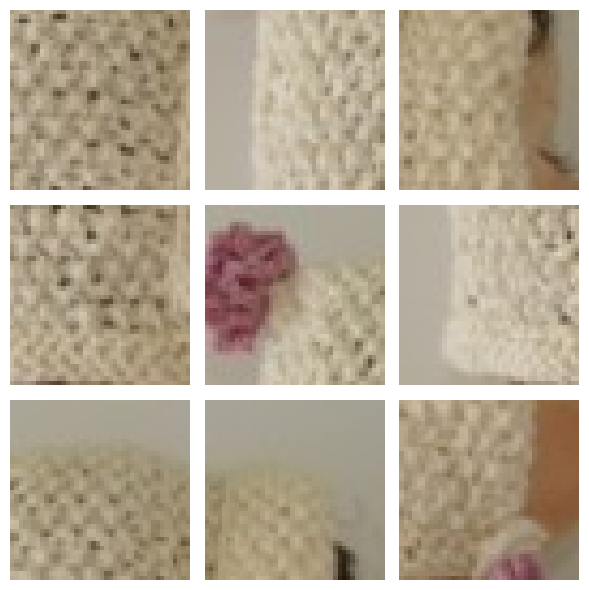

In [ ]:
# unscramble_jigsaw(permutation_set[train_data[0][1]], train_data[0][0], 3)
shuffled_patches, perm_index = train_data[0]
plt.subplots(1, 2, 1)
unscramble_jigsaw(permutation_set[perm_index], shuffled_patches, 3)
visualize_jigsaw(shuffled_patches, 3)

In [35]:
import os
print(f"Cpu count: {os.cpu_count()}")

Cpu count: 12
